In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy
from mne.filter import filter_data

### Config

In [2]:
CHANNEL_NAMES = [
    "FP1", "F3",  "F7",  "C3",
    "T3",  "P3",  "T5",  "O1",
    "FP2", "F4",  "F8",  "C4",
    "T4",  "P4",  "T6",  "O2"
]

SUBJECT = "X"
ROOT    = f"../data/subject{SUBJECT}"
DATE    = "20260618"

files  = [f for f in os.listdir(ROOT) if f.endswith(".csv")]
STAMPS = np.unique([f.split("_")[-1][:-4] for f in files if f"{SUBJECT}_eeg_{DATE}" in f])

STAMP_ID = 0
STAMP    = STAMPS[STAMP_ID]
print(f"Available: {STAMPS}")
print(f"Loading   STAMP={STAMP}")

FS = 250.

# Stimulus-locked window (around onset)
PRE_STIM  = 0.2   # s before stimulus
POST_STIM = 2.0   # s after stimulus

# Movement-locked window (around button press)
PRE_PRESS  = 2.0  # s before press  (captures BP ramp)
POST_PRESS = 0.5  # s after press

Available: ['101323']
Loading   STAMP=101323


#### Load data

In [3]:
# Loading EEG
df_eeg     = pd.read_csv(f"{ROOT}/{SUBJECT}_eeg_{DATE}_{STAMP}.csv")
timestamps = df_eeg.lsl_timestamp.values
EEG        = df_eeg.iloc[:, 1:-1].values
button     = df_eeg.iloc[:, -1].values.astype(bool)

N, N_CHANNELS = EEG.shape
print(f"EEG shape: {EEG.shape}  ({N / FS:.1f} s)")

EEG shape: (267752, 16)  (1071.0 s)


In [4]:
# Loading markers
df_markers = pd.read_csv(f"{ROOT}/{SUBJECT}_markers_{DATE}_{STAMP}.csv")

#### Align marker timestamps to EEG clock

EEG timestamps are saved with `time_correction` applied (wall-clock reference),
but markers used raw `local_clock()` (boot-relative).  
We recover the offset using the first button-press rising edge visible in both signals.

> **Fixed in `gng_task.py`** — future sessions won't need this cell.

In [5]:
# Rising edges in EEG button channel (ch16)
BUTTON_EDGES = np.where(np.diff(button.astype(int)) > 0)[0]

# Prefer SP press as anchor; fall back to first GO hit if no SP block was run
SP_MKR_TIMES      = df_markers.loc[df_markers.marker_code == 41].lsl_timestamp.values
GO_PRESS_MKR_TIMES = df_markers.loc[
    (df_markers.marker_code == 30) & (df_markers.trial_type == "go")
].lsl_timestamp.values

HAS_SP = len(SP_MKR_TIMES) > 0

if len(BUTTON_EDGES) > 0 and HAS_SP:
    EEG_FIRST_PRESS = timestamps[BUTTON_EDGES[0] + 1]
    MKR_FIRST_PRESS = SP_MKR_TIMES[0]
    anchor          = "selfpaced_press (code 41)"
elif len(BUTTON_EDGES) > 0 and len(GO_PRESS_MKR_TIMES) > 0:
    EEG_FIRST_PRESS = timestamps[BUTTON_EDGES[0] + 1]
    MKR_FIRST_PRESS = GO_PRESS_MKR_TIMES[0]
    anchor          = "go_press (code 30) — no SP block"
else:
    EEG_FIRST_PRESS = MKR_FIRST_PRESS = None
    anchor          = None

if EEG_FIRST_PRESS is not None:
    TS_OFFSET = EEG_FIRST_PRESS - MKR_FIRST_PRESS
    df_markers["lsl_timestamp"] = df_markers["lsl_timestamp"] + TS_OFFSET
    print(f"TS_OFFSET = {TS_OFFSET:.3f} s  (anchor: {anchor})")
else:
    TS_OFFSET = 0.0
    print("WARNING: could not compute TS_OFFSET — check BUTTON_EDGES and marker file")

TS_OFFSET = 1781276233.288 s  (anchor: selfpaced_press (code 41))


In [6]:
df_eeg.head()

,lsl_timestamp,ch0,ch1,ch2,ch3,ch4,ch5,ch6,ch7,ch8,ch9,ch10,ch11,ch12,ch13,ch14,ch15,ch16
0,1.781811e+09,-69388.476562,-48542.621094,-76736.929688,87602.562500,-16805.109375,-1590.550049,-75213.710938,-42676.359375,-89829.601562,1702.670044,-89470.453125,1074564.375,902828.9375,-94792.492188,-22978.490234,-66733.359375,0.0
1,1.781811e+09,-69284.148438,-48382.230469,-76552.929688,87415.070312,-16955.849609,-1670.479980,-75263.859375,-42828.710938,-90230.593750,1806.199951,-89552.257812,1074703.500,902940.0000,-94934.109375,-22934.230469,-66707.882812,0.0
2,1.781811e+09,-69393.851562,-48537.789062,-76814.179688,87555.890625,-16817.990234,-1572.040039,-75239.992188,-42675.289062,-90883.710938,2127.260010,-89699.507812,1074977.375,903183.7500,-95217.617188,-22914.109375,-66693.671875,0.0
3,1.781811e+09,-69573.023438,-48809.500000,-77183.250000,87854.960938,-16553.250000,-1407.890015,-75161.937500,-42396.878906,-90851.789062,2206.649902,-89704.070312,1075060.500,903237.4375,-95240.960938,-22946.029297,-66705.203125,0.0
4,1.781811e+09,-69579.992188,-48822.109375,-77138.726562,87860.593750,-16559.150391,-1428.280029,-75158.179688,-42412.968750,-90162.460938,1924.489990,-89552.531250,1074782.375,903045.3750,-94961.203125,-22979.019531,-66718.609375,0.0


In [7]:
df_markers.head(20)

,lsl_timestamp,marker_code,marker_label,trial_type
0,1.781811e+09,40,selfpaced_start,selfpaced
1,1.781811e+09,41,selfpaced_press,selfpaced
2,1.781811e+09,41,selfpaced_press,selfpaced
3,1.781811e+09,41,selfpaced_press,selfpaced
4,1.781811e+09,41,selfpaced_press,selfpaced
5,1.781811e+09,41,selfpaced_press,selfpaced
6,1.781811e+09,41,selfpaced_press,selfpaced
7,1.781811e+09,41,selfpaced_press,selfpaced
8,1.781811e+09,41,selfpaced_press,selfpaced
9,1.781811e+09,41,selfpaced_press,selfpaced


In [8]:
df_markers.trial_type.value_counts()

trial_type
go           300
nogo         201
selfpaced     59
Name: count, dtype: int64

### Preprocess EEG

In [9]:
EEG = filter_data(EEG.T[None], FS, 0.5, 40., verbose=False).squeeze()

In [10]:
# Apply CAR
EEG -= EEG.mean(axis=0, keepdims=True)

---
## Stimulus-locked ERPs: GO vs NOGO

Epochs locked to stimulus onset.  
Look for **N2** (~200 ms) and **P3** (~300–400 ms), largest at frontocentral electrodes.

| Marker code | Event      |
|-------------|------------|
| 10          | go_onset   |
| 20          | nogo_onset |

In [11]:
N_PRE_STIM  = int(PRE_STIM  * FS)
N_POST_STIM = int(POST_STIM * FS)
N_STIM      = N_PRE_STIM + N_POST_STIM + 1
T_STIM      = np.linspace(-PRE_STIM, POST_STIM, N_STIM)

In [12]:
go_onsets = df_markers.loc[df_markers.marker_code == 10].lsl_timestamp.values

GO_ERP = []
for onset in go_onsets:
    idx = np.searchsorted(timestamps, onset)
    i0  = idx - N_PRE_STIM
    i1  = idx + N_POST_STIM + 1
    if i0 >= 0 and i1 <= N:
        GO_ERP.append(EEG[:, i0:i1])

GO_ERP = np.stack(GO_ERP)
print(f"GO epochs: {len(GO_ERP)}")

GO epochs: 99


In [13]:
nogo_onsets = df_markers.loc[df_markers.marker_code == 20].lsl_timestamp.values

NOGO_ERP = []
for onset in nogo_onsets:
    idx = np.searchsorted(timestamps, onset)
    i0  = idx - N_PRE_STIM
    i1  = idx + N_POST_STIM + 1
    if i0 >= 0 and i1 <= N:
        NOGO_ERP.append(EEG[:, i0:i1])

NOGO_ERP = np.stack(NOGO_ERP)
print(f"NOGO epochs: {len(NOGO_ERP)}")

NOGO epochs: 100


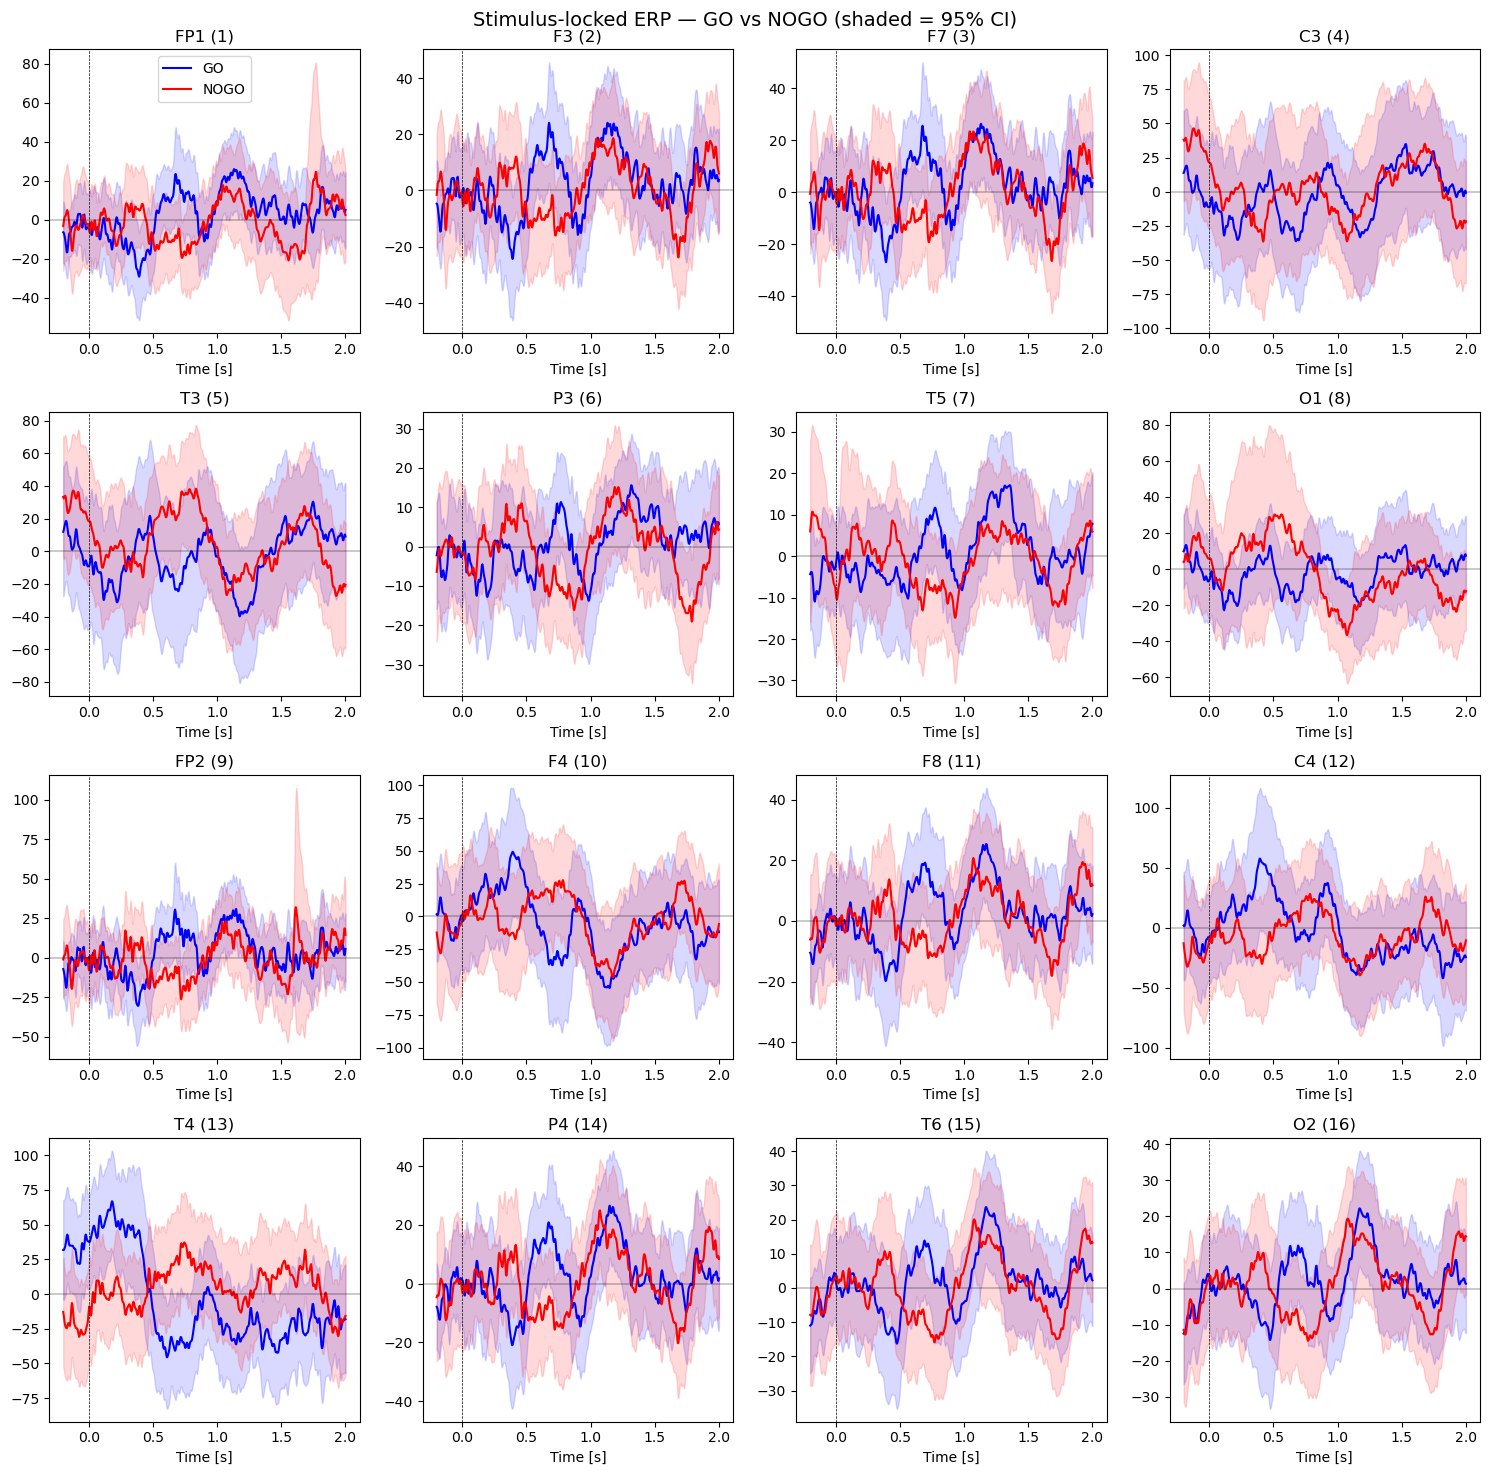

In [14]:
import numpy as np

def _ci(erp):
    """(N, CH, T) -> three (CH, T) arrays: mean, lower 95% CI, upper 95% CI."""
    n   = erp.shape[0]
    mu  = erp.mean(0)
    sem = erp.std(0) / np.sqrt(n)
    return mu, mu - 1.96*sem, mu + 1.96*sem

plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    ax = plt.subplot(4, 4, pos + 1)
    for erp, color, label in [(GO_ERP, 'b', 'GO'), (NOGO_ERP, 'r', 'NOGO')]:
        mu, lo, hi = _ci(erp)
        ax.plot(T_STIM, mu[pos], color=color, label=label)
        ax.fill_between(T_STIM, lo[pos], hi[pos], color=color, alpha=0.15)
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.axhline(0, color='k', linewidth=0.3)
    ax.set_title(f'{CHANNEL_NAMES[pos]} ({pos+1})')
    ax.set_xlabel('Time [s]')
    if pos == 0:
        ax.legend()
plt.suptitle('Stimulus-locked ERP — GO vs NOGO (shaded = 95% CI)', fontsize=14)
plt.tight_layout()


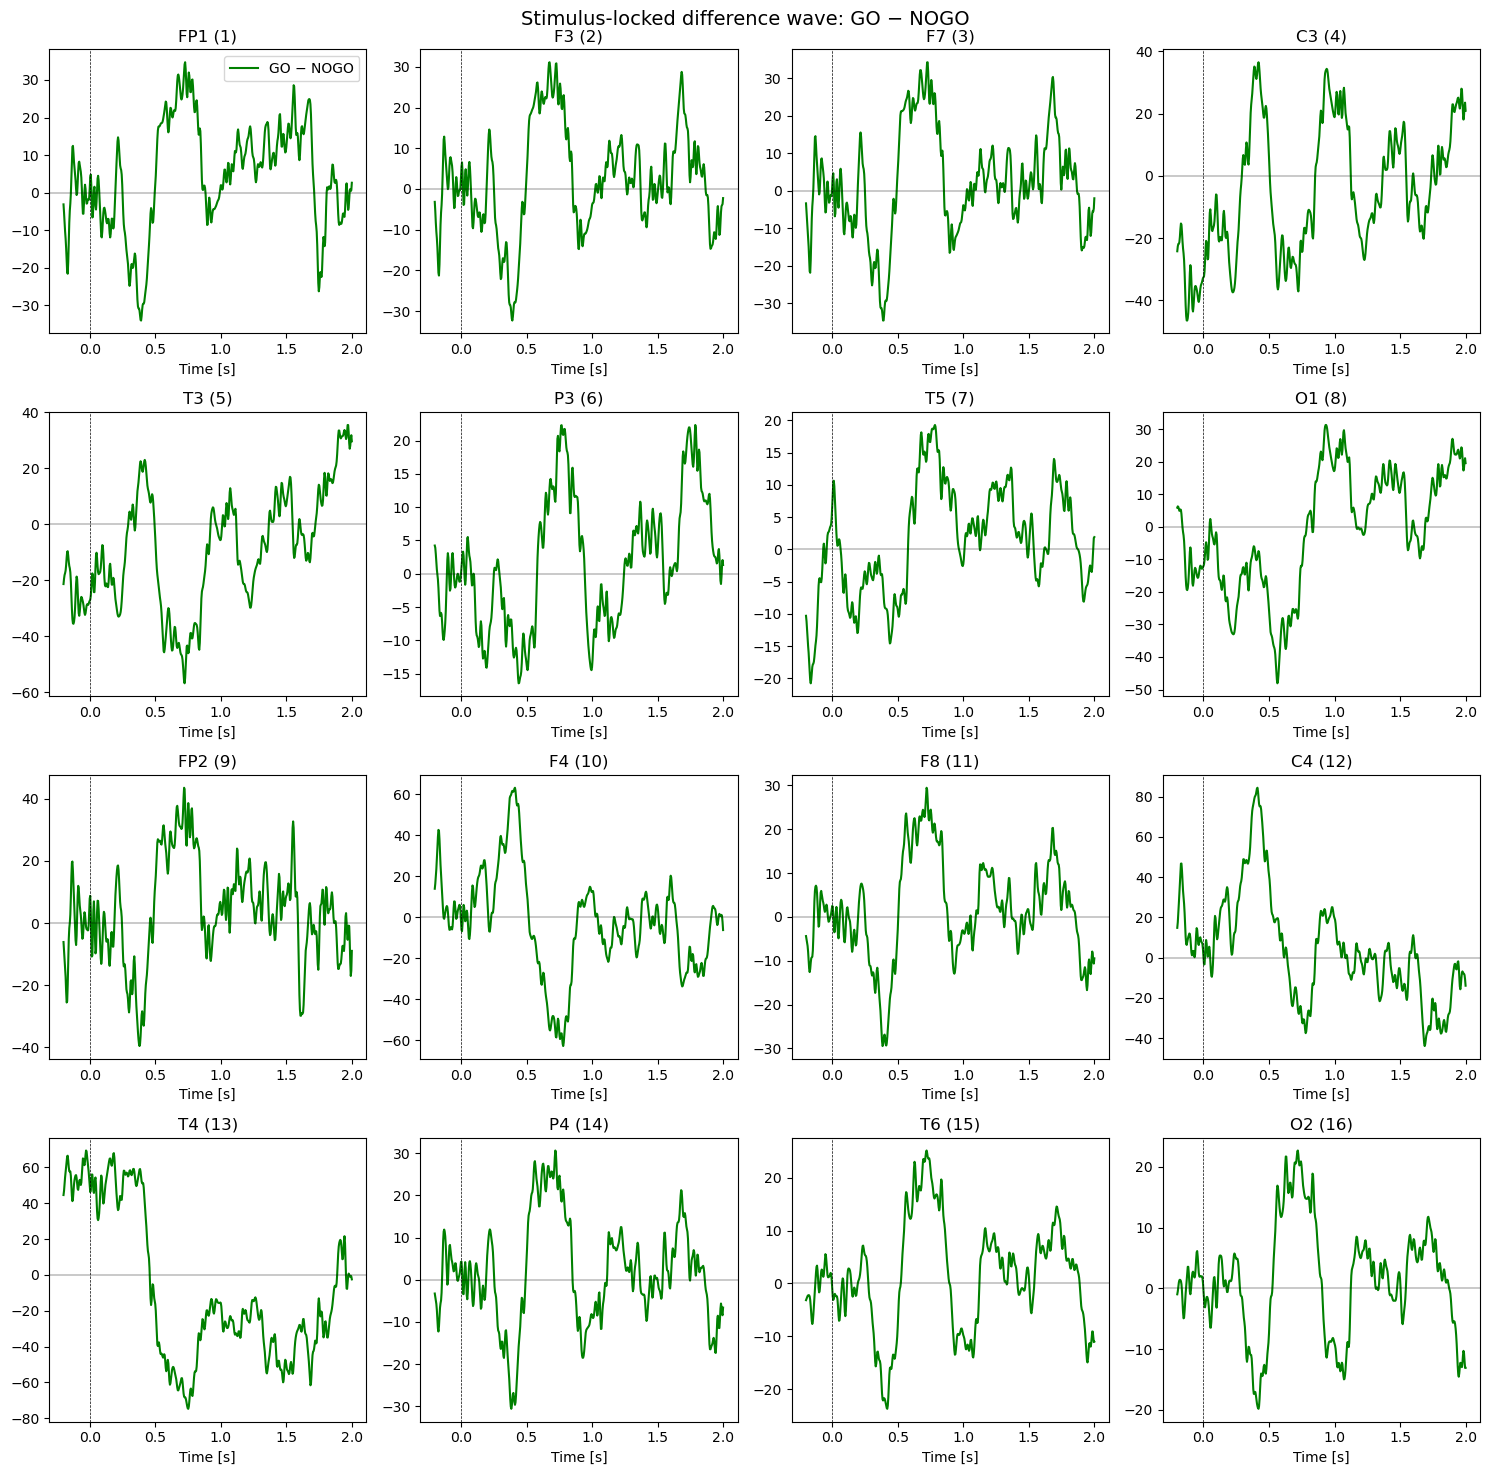

In [15]:
# GO - NOGO difference wave
GO_MINUS_NOGO = GO_ERP.mean(axis=0) - NOGO_ERP.mean(axis=0)

plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    plt.subplot(4, 4, pos + 1)
    plt.plot(T_STIM, GO_MINUS_NOGO[pos], "g", label="GO − NOGO")
    plt.axvline(0, color="k", linewidth=0.5, linestyle="--")
    plt.axhline(0, color="k", linewidth=0.3)
    plt.title(f"{CHANNEL_NAMES[pos]} ({pos + 1})")
    plt.xlabel("Time [s]")
    if pos == 0:
        plt.legend()
plt.suptitle("Stimulus-locked difference wave: GO − NOGO", fontsize=14)
plt.tight_layout()

---
## Movement-locked ERPs: GO hit vs Self-paced

Epochs locked to **button press**.  
Look for the **Bereitschaftspotential** — slow negative ramp starting ~1–1.5 s before press, maximal at **Cz** (ch C3, index 3 in this cap).

| Marker code | Event             |
|-------------|-------------------|
| 30          | button_press (GO) |
| 41          | selfpaced_press   |

In [16]:
N_PRE_PRESS  = int(PRE_PRESS  * FS)
N_POST_PRESS = int(POST_PRESS * FS)
N_PRESS      = N_PRE_PRESS + N_POST_PRESS + 1
T_PRESS      = np.linspace(-PRE_PRESS, POST_PRESS, N_PRESS)

In [17]:
# GO hits only (button_press on go trials)
go_press_times = df_markers.loc[
    (df_markers.marker_code == 30) & (df_markers.trial_type == "go")
].lsl_timestamp.values

GO_PRESS_ERP = []
for t in go_press_times:
    idx = np.searchsorted(timestamps, t)
    i0  = idx - N_PRE_PRESS
    i1  = idx + N_POST_PRESS + 1
    if i0 >= 0 and i1 <= N:
        GO_PRESS_ERP.append(EEG[:, i0:i1])

GO_PRESS_ERP = np.stack(GO_PRESS_ERP)
print(f"GO hit press epochs: {len(GO_PRESS_ERP)}")

GO hit press epochs: 99


In [18]:
# Self-paced presses (voluntary, no cue)
sp_press_times = df_markers.loc[df_markers.marker_code == 41].lsl_timestamp.values
print(f"Self-paced press events found: {len(sp_press_times)}")

SP_ERP = []
for t in sp_press_times:
    idx = np.searchsorted(timestamps, t)
    i0  = idx - N_PRE_PRESS
    i1  = idx + N_POST_PRESS + 1
    if i0 >= 0 and i1 <= N:
        SP_ERP.append(EEG[:, i0:i1])

SP_ERP = np.stack(SP_ERP) if SP_ERP else None
print(f"SP epochs after boundary check: {len(SP_ERP) if SP_ERP is not None else 0}")

Self-paced press events found: 57
SP epochs after boundary check: 56


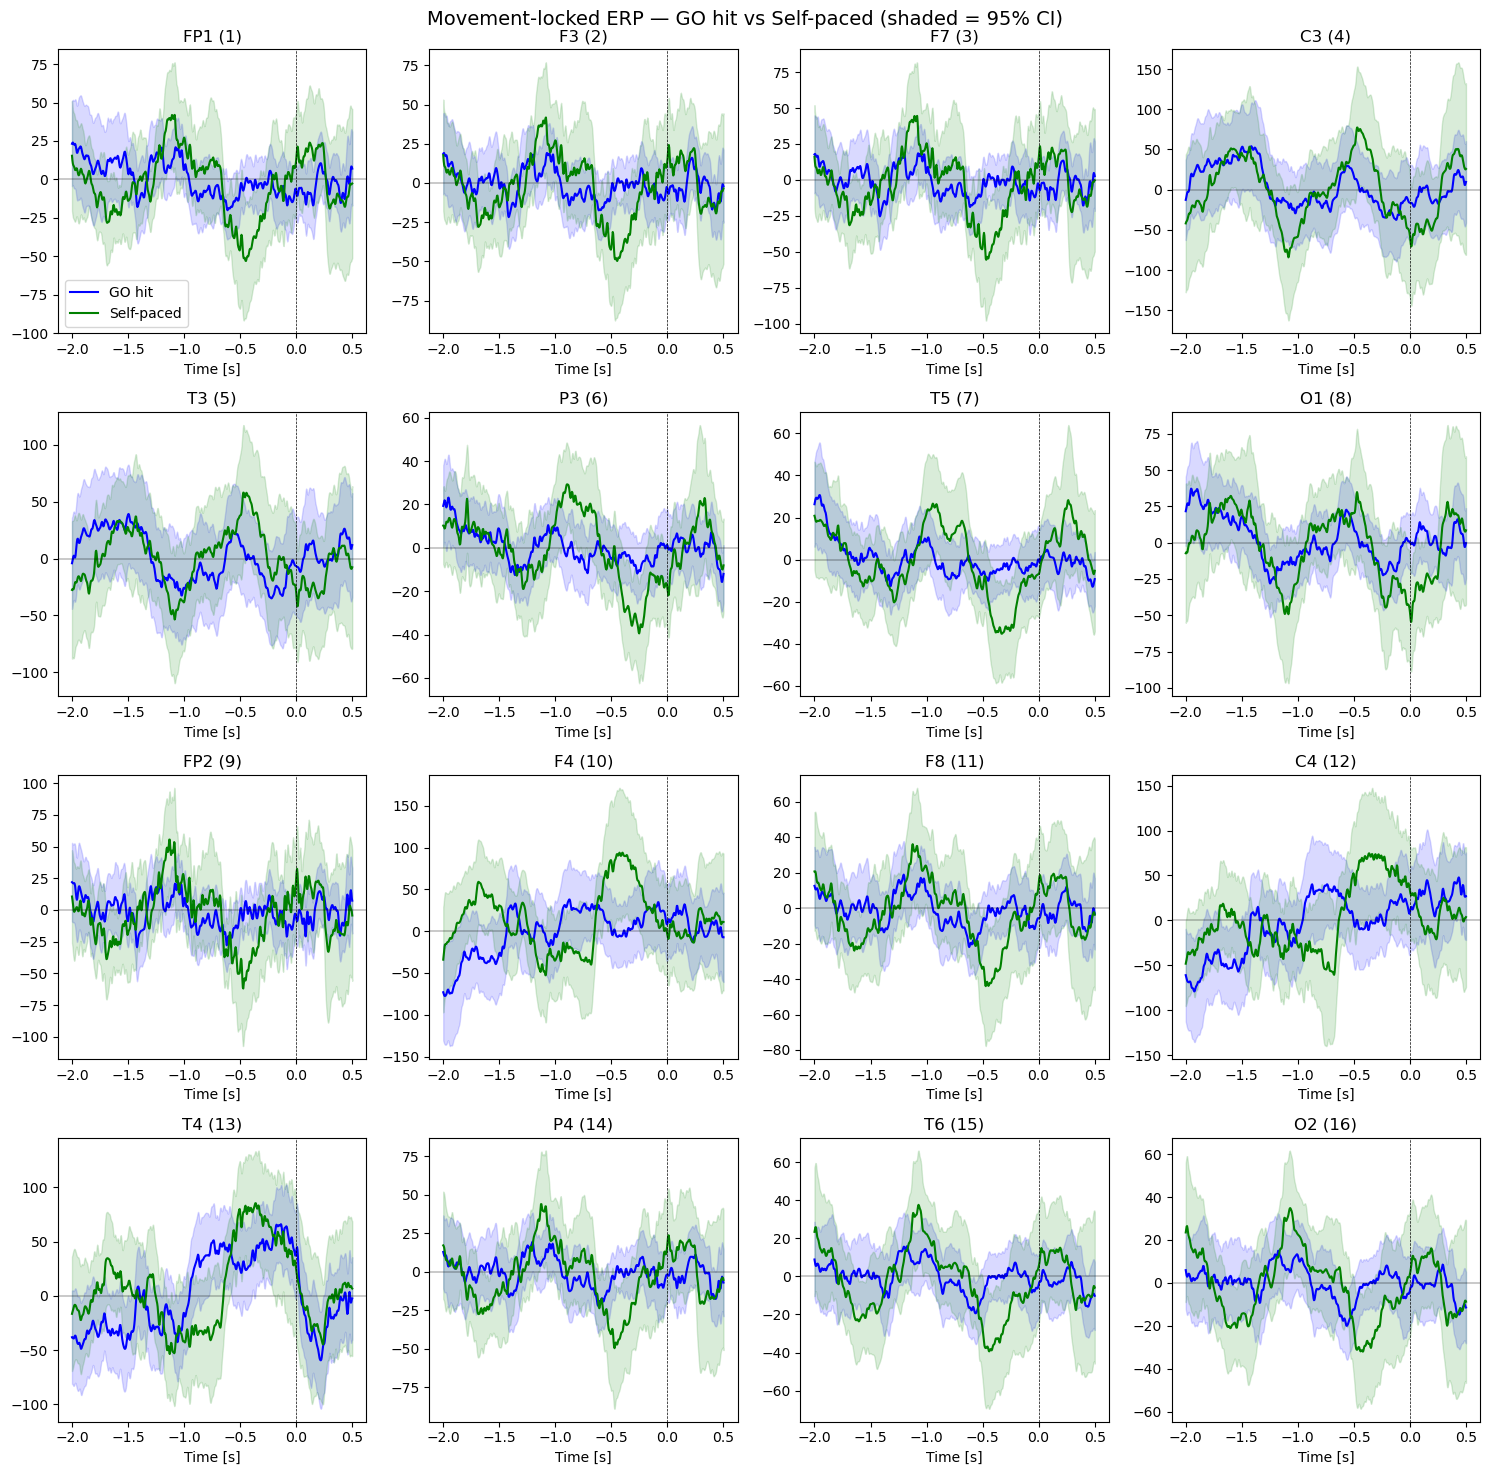

In [19]:
plt.figure(figsize=(15, 15))
for pos in range(N_CHANNELS):
    ax = plt.subplot(4, 4, pos + 1)
    for erp, color, label in [(GO_PRESS_ERP, 'b', 'GO hit'), (SP_ERP, 'g', 'Self-paced')]:
        if erp is None: continue
        mu, lo, hi = _ci(erp)
        ax.plot(T_PRESS, mu[pos], color=color, label=label)
        ax.fill_between(T_PRESS, lo[pos], hi[pos], color=color, alpha=0.15)
    ax.axvline(0, color='k', linewidth=0.5, linestyle='--')
    ax.axhline(0, color='k', linewidth=0.3)
    ax.set_title(f'{CHANNEL_NAMES[pos]} ({pos+1})')
    ax.set_xlabel('Time [s]')
    if pos == 0:
        ax.legend()
plt.suptitle('Movement-locked ERP — GO hit vs Self-paced (shaded = 95% CI)', fontsize=14)
plt.tight_layout()


---
## Summary: all conditions at Cz

Cz is channel index 3 (C3 in this 16-ch cap — adjust `CZ` if needed).  
Stimulus-locked and movement-locked have different time axes — plotted side by side.

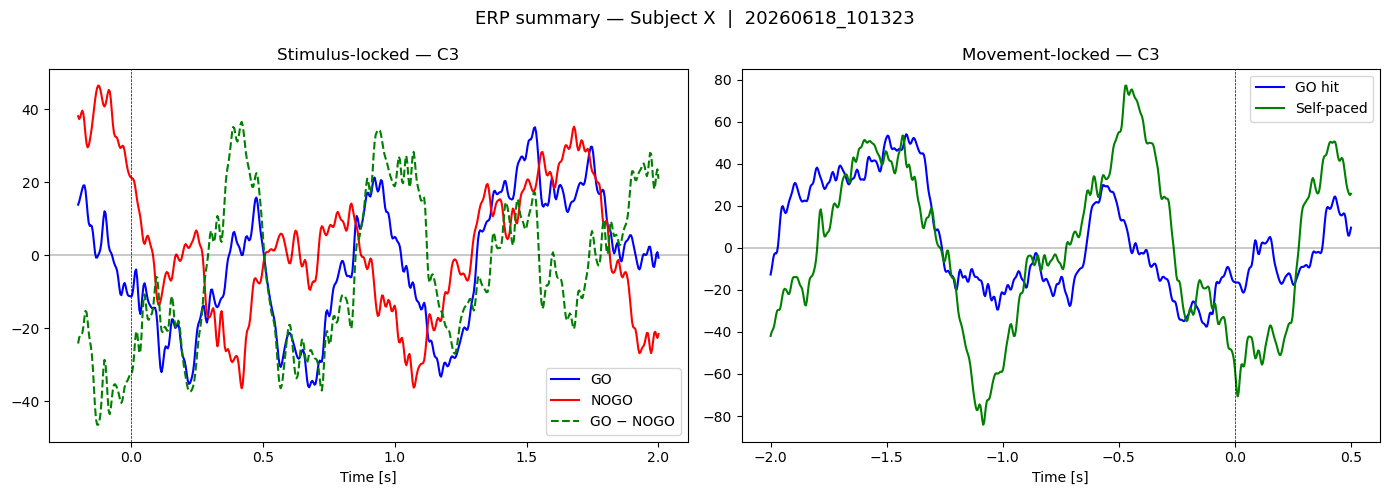

In [20]:
CZ = 3  # C3 position in this cap — adjust if your Cz is different

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
ax.plot(T_STIM, GO_ERP.mean(0)[CZ],   "b",   label="GO")
ax.plot(T_STIM, NOGO_ERP.mean(0)[CZ], "r",   label="NOGO")
ax.plot(T_STIM, GO_MINUS_NOGO[CZ],    "g--", label="GO − NOGO")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.axhline(0, color="k", linewidth=0.3)
ax.set_xlabel("Time [s]")
ax.set_title(f"Stimulus-locked — {CHANNEL_NAMES[CZ]}")
ax.legend()

ax = axes[1]
ax.plot(T_PRESS, GO_PRESS_ERP.mean(0)[CZ], "b", label="GO hit")
if SP_ERP is not None:
    ax.plot(T_PRESS, SP_ERP.mean(0)[CZ], "g", label="Self-paced")
ax.axvline(0, color="k", linewidth=0.5, linestyle="--")
ax.axhline(0, color="k", linewidth=0.3)
ax.set_xlabel("Time [s]")
ax.set_title(f"Movement-locked — {CHANNEL_NAMES[CZ]}")
ax.legend()

plt.suptitle(f"ERP summary — Subject {SUBJECT}  |  {DATE}_{STAMP}", fontsize=13)
plt.tight_layout()

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score
import numpy as np

N_SEGS = 4

def augment(epochs, n_aug=5, noise_std=0.15, scale_range=(0.8, 1.2), rng=None):
    """(N, CH, T) -> (N*(1+n_aug), CH, T) — noise + amplitude scaling."""
    rng = np.random.default_rng(rng)
    aug = [epochs]
    for _ in range(n_aug):
        noise = rng.standard_normal(epochs.shape) * epochs.std(axis=2, keepdims=True) * noise_std
        scale = rng.uniform(*scale_range, size=(len(epochs), 1, 1))
        aug.append(epochs * scale + noise)
    return np.concatenate(aug, axis=0)

def epoch_feats(epochs):
    """(N, CH, T) -> (N, CH*(3+N_SEGS)) — mean, std, slope, line-length per segment."""
    N, CH, T = epochs.shape
    t_c  = np.arange(T, dtype=np.float64) - T / 2
    slope = (epochs * t_c).sum(axis=2) / (t_c ** 2).sum()   # (N, CH)

    seg = T // N_SEGS
    ll  = np.stack([
              np.abs(np.diff(epochs[:, :, i*seg:(i+1)*seg], axis=2)).sum(axis=2)
              for i in range(N_SEGS)
          ], axis=2).reshape(N, CH * N_SEGS)                 # (N, CH*N_SEGS)
    
    return np.concatenate([
        epochs.mean(axis=2),
        epochs.std(axis=2),
        epochs.max(axis=2),
        epochs.min(axis=2),
        slope,
        ll,
    ], axis=1)                                               # (N, CH*(3+N_SEGS))

N_SP   = SP_ERP.shape[0]
N_GO   = GO_PRESS_ERP.shape[0]
N      = N_SP + N_GO
y_real = np.array([0] * N_GO + [1] * N_SP)

epochs_real = np.concatenate([GO_PRESS_ERP, SP_ERP], axis=0)  # (N, CH, T)
X_real      = epoch_feats(epochs_real)

N_AUG     = 5
rng       = np.random.default_rng(42)
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_proto = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=1000))

aucs, accs = [], []
for train_idx, test_idx in cv.split(X_real, y_real):
    ep_tr = augment(epochs_real[train_idx], n_aug=N_AUG, rng=rng)
    X_tr  = epoch_feats(ep_tr)
    y_tr  = np.tile(y_real[train_idx], N_AUG + 1)
    clf   = clone(clf_proto)
    clf.fit(X_tr, y_tr)
    prob  = clf.predict_proba(X_real[test_idx])[:, 1]
    aucs.append(roc_auc_score(y_real[test_idx], prob))
    accs.append(accuracy_score(y_real[test_idx], clf.predict(X_real[test_idx])))

print(f"GO (n={N_GO}) vs SP (n={N_SP})  |  5-fold CV  |  {N_AUG}x augmentation (train only)")
print(f"  AUC  = {np.mean(aucs):.3f} \u00b1 {np.std(aucs):.3f}")
print(f"  ACC  = {np.mean(accs):.3f} \u00b1 {np.std(accs):.3f}")
print(f"  chance = {max(N_GO, N_SP) / N:.2f}")
print(f"  features: {X_real.shape[1]}  ({N_CHANNELS} ch x {3+N_SEGS} feats/ch)")


GO (n=99) vs SP (n=56)  |  5-fold CV  |  5x augmentation (train only)
  AUC  = 0.924 ± 0.042
  ACC  = 0.858 ± 0.052
  chance = 0.64
  features: 144  (16 ch x 7 feats/ch)


GO box epochs: 100,  SP box epochs: 56


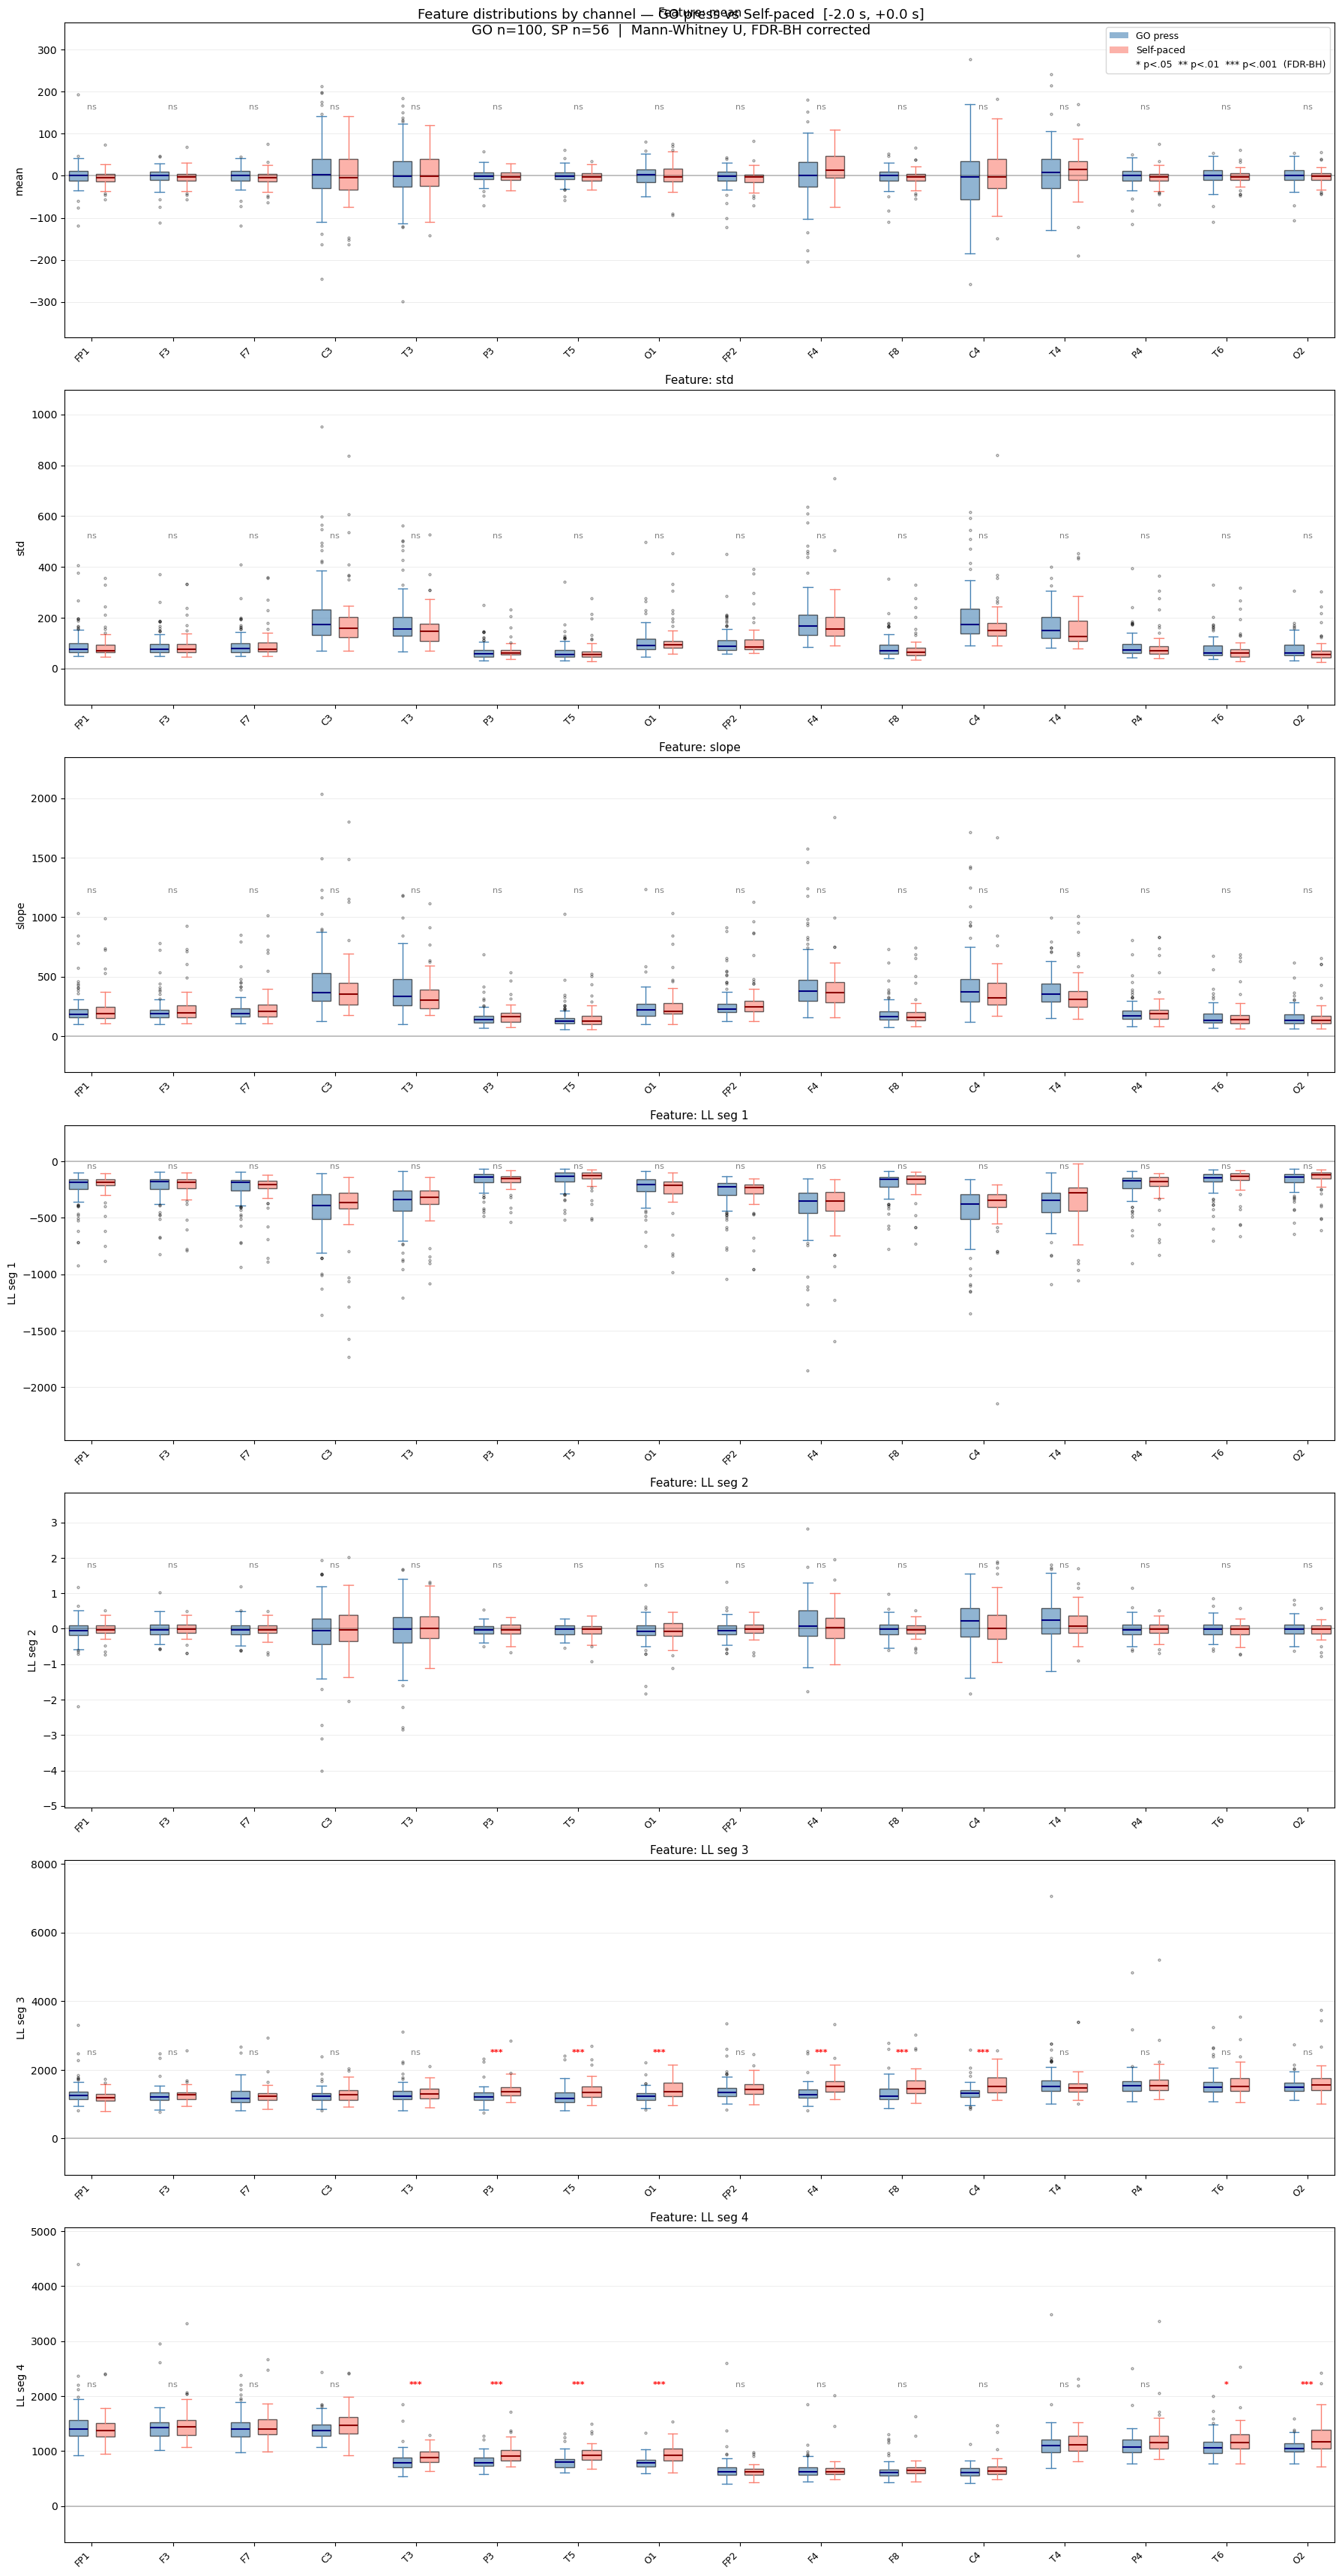

In [29]:
# ── Feature boxplots: GO press vs Self-paced  [-1.5 s, +0.8 s] ─────────────────
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

PRE_BOX  = 2.   # s before press
POST_BOX = 0   # s after press
N_PRE_BOX  = int(PRE_BOX  * FS)
N_POST_BOX = int(POST_BOX * FS)

def extract_epochs(press_times, pre, post):
    eps = []
    for t in press_times:
        idx = np.searchsorted(timestamps, t)
        i0, i1 = idx - pre, idx + post + 1
        if i0 >= 0 and i1 <= len(timestamps):
            eps.append(EEG[:, i0:i1])
    return np.stack(eps) if eps else None

GO_BOX = extract_epochs(go_press_times, N_PRE_BOX, N_POST_BOX)
SP_BOX = extract_epochs(sp_press_times, N_PRE_BOX, N_POST_BOX)
print(f"GO box epochs: {len(GO_BOX)},  SP box epochs: {len(SP_BOX)}")

X_go = epoch_feats(GO_BOX)   # (N_go, CH*(3+N_SEGS))
X_sp = epoch_feats(SP_BOX)   # (N_sp, CH*(3+N_SEGS))

feat_types   = ['mean', 'std', 'slope'] + [f'LL seg {i+1}' for i in range(N_SEGS)]
n_feat_types = len(feat_types)
n_feats_total = n_feat_types * N_CHANNELS

# ── FDR correction across all feature×channel pairs ──────────────────────────
raw_pvals = []
for fi in range(n_feat_types):
    for ch in range(N_CHANNELS):
        col = fi * N_CHANNELS + ch
        _, p = mannwhitneyu(X_go[:, col], X_sp[:, col], alternative='two-sided')
        raw_pvals.append(p)

_, pvals_fdr, _, _ = multipletests(raw_pvals, method='fdr_bh')
pvals_fdr = pvals_fdr.reshape(n_feat_types, N_CHANNELS)

def pval_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_feat_types, 1, figsize=(18, 5 * n_feat_types), sharex=False)

for fi, (ftype, ax) in enumerate(zip(feat_types, axes)):
    cols      = np.arange(fi * N_CHANNELS, (fi + 1) * N_CHANNELS)
    go_vals   = [X_go[:, c] for c in cols]
    sp_vals   = [X_sp[:, c] for c in cols]

    positions_go = np.arange(N_CHANNELS) * 3
    positions_sp = positions_go + 1

    bp_go = ax.boxplot(go_vals, positions=positions_go, widths=0.7,
                       patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6),
                       medianprops=dict(color='navy', linewidth=1.5),
                       whiskerprops=dict(color='steelblue'),
                       capprops=dict(color='steelblue'),
                       flierprops=dict(marker='o', markersize=2, color='steelblue', alpha=0.4))

    bp_sp = ax.boxplot(sp_vals, positions=positions_sp, widths=0.7,
                       patch_artist=True,
                       boxprops=dict(facecolor='salmon', alpha=0.6),
                       medianprops=dict(color='darkred', linewidth=1.5),
                       whiskerprops=dict(color='salmon'),
                       capprops=dict(color='salmon'),
                       flierprops=dict(marker='o', markersize=2, color='salmon', alpha=0.4))

    # significance annotation per channel
    y_top = ax.get_ylim()[1]
    all_tops = [max(np.percentile(go_vals[ch], 95), np.percentile(sp_vals[ch], 95))
                for ch in range(N_CHANNELS)]
    y_annot = max(all_tops) * 1.05

    for ch in range(N_CHANNELS):
        p   = pvals_fdr[fi, ch]
        lbl = pval_stars(p)
        mid = (positions_go[ch] + positions_sp[ch]) / 2
        color = 'red' if p < 0.05 else 'gray'
        ax.text(mid, y_annot, lbl, ha='center', va='bottom', fontsize=8,
                color=color, fontweight='bold' if p < 0.05 else 'normal')

    ax.set_xticks(positions_go + 0.5)
    ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(ftype, fontsize=10)
    ax.axhline(0, color='k', linewidth=0.3)
    ax.set_title(f'Feature: {ftype}', fontsize=11)
    ax.grid(axis='y', linewidth=0.4, alpha=0.4)
    ax.margins(y=0.15)

    if fi == 0:
        ax.legend(handles=[Patch(facecolor='steelblue', alpha=0.6, label='GO press'),
                            Patch(facecolor='salmon',    alpha=0.6, label='Self-paced'),
                            plt.Line2D([], [], color='none', label='* p<.05  ** p<.01  *** p<.001  (FDR-BH)')],
                  loc='upper right', fontsize=9)

plt.suptitle(
    f'Feature distributions by channel — GO press vs Self-paced  '
    f'[{-PRE_BOX:.1f} s, +{POST_BOX:.1f} s]\n'
    f'GO n={len(GO_BOX)}, SP n={len(SP_BOX)}  |  Mann-Whitney U, FDR-BH corrected',
    fontsize=13
)
plt.tight_layout()
plt.show()


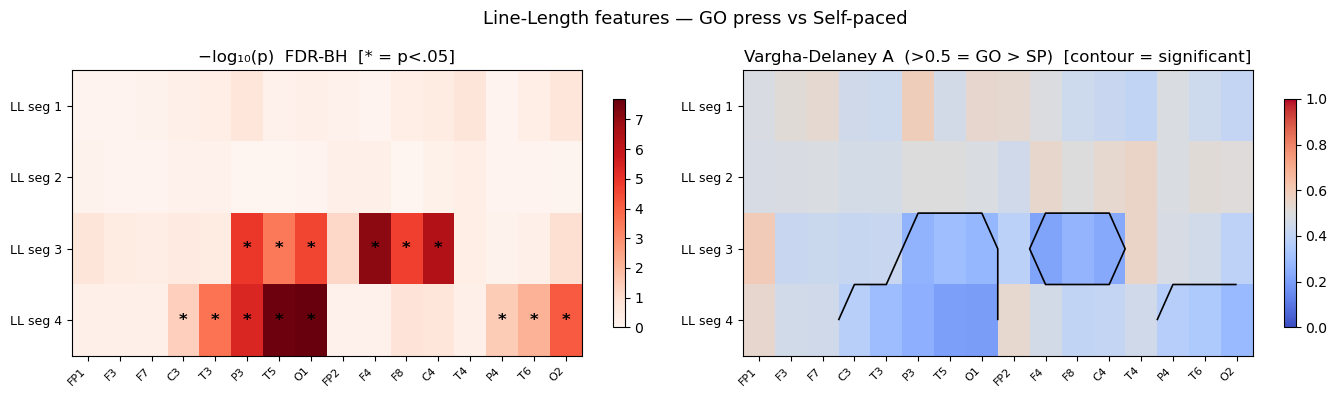

Significant LL features (FDR p<.05): 14


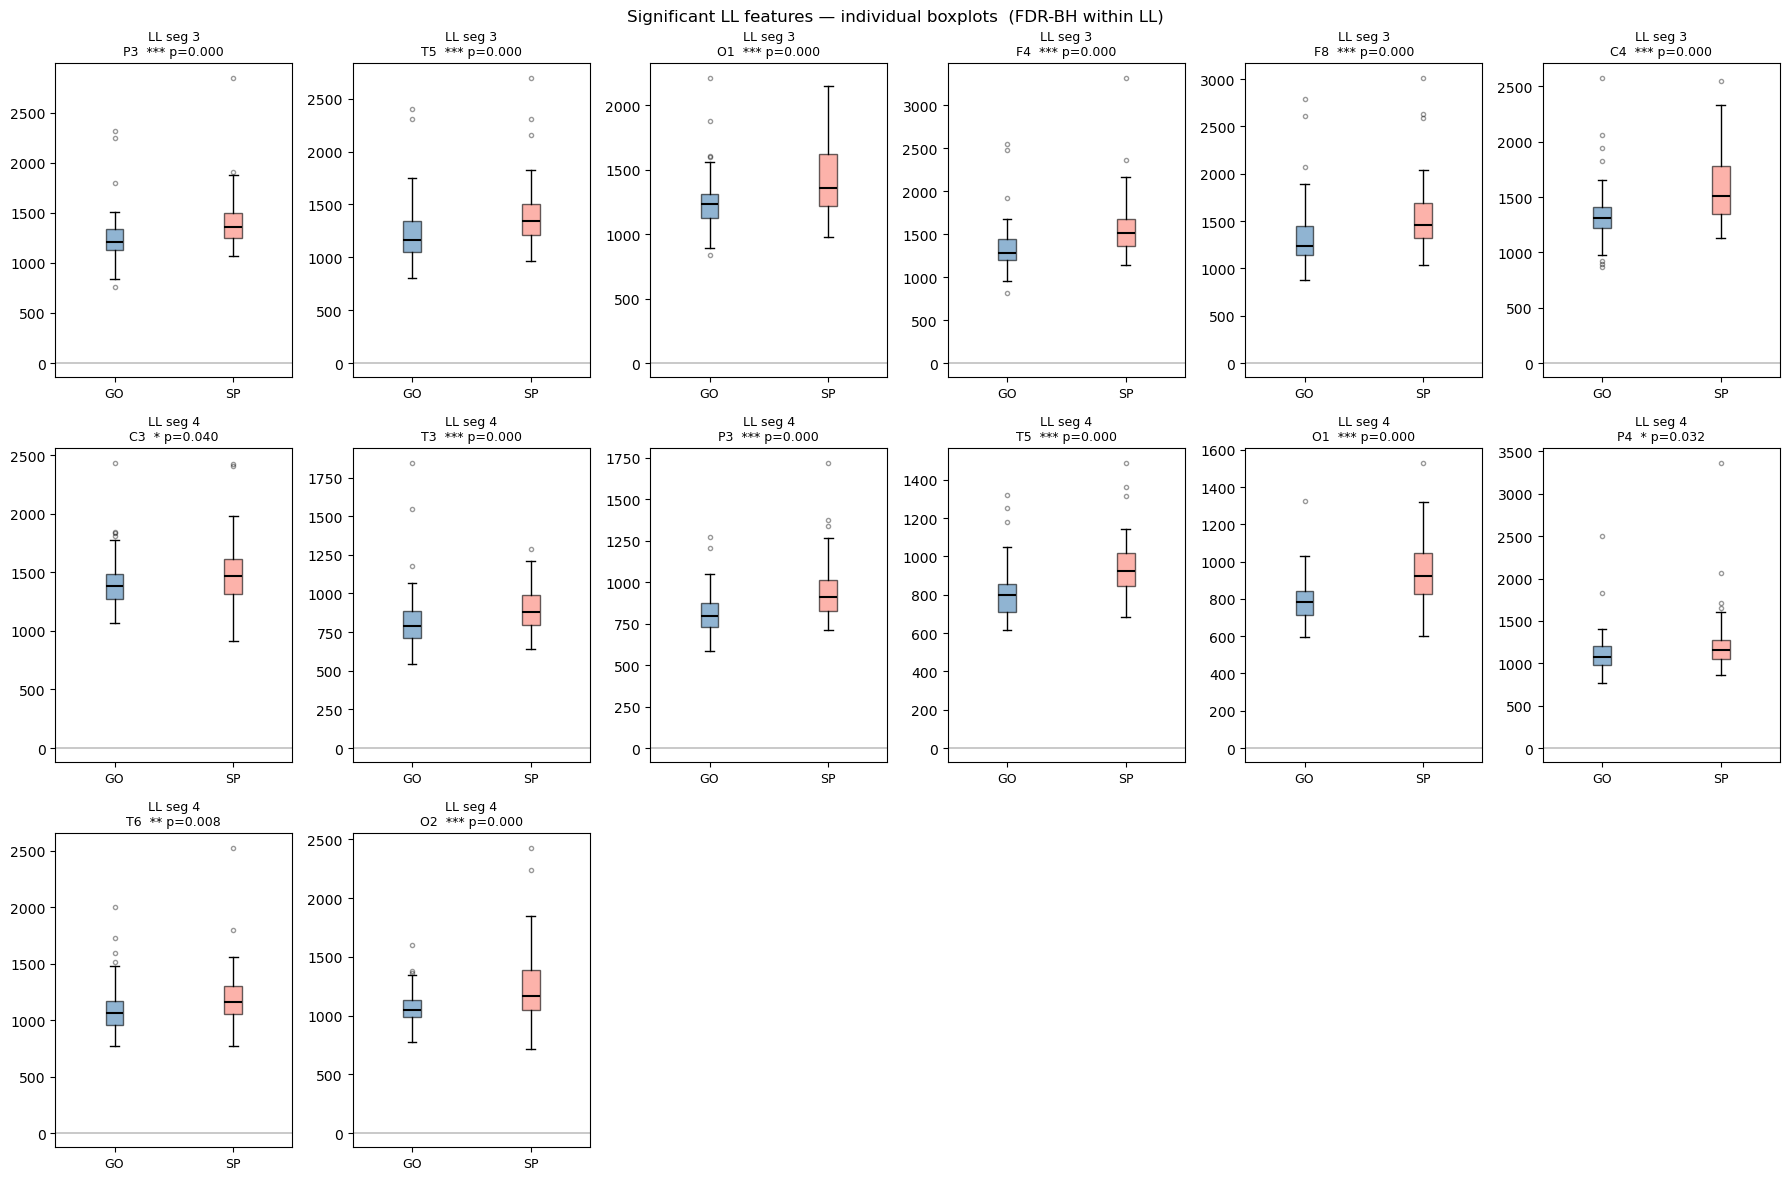

In [28]:
# ── Significant LL features: focused view ────────────────────────────────────
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

LL_FEAT_NAMES = [f'LL seg {i+1}' for i in range(N_SEGS)]
LL_START_COL  = 3 * N_CHANNELS          # mean + std + slope come first

# Gather LL cols and recompute FDR within LL only (more power)
ll_cols   = np.arange(LL_START_COL, LL_START_COL + N_SEGS * N_CHANNELS)
raw_p_ll  = []
for col in ll_cols:
    _, p = mannwhitneyu(X_go[:, col], X_sp[:, col], alternative='two-sided')
    raw_p_ll.append(p)

_, pvals_ll_fdr, _, _ = multipletests(raw_p_ll, method='fdr_bh')
pvals_ll_fdr = pvals_ll_fdr.reshape(N_SEGS, N_CHANNELS)

# Common-language effect size (Vargha-Delaney A)
def vda(a, b):
    n_a, n_b = len(a), len(b)
    u, _ = mannwhitneyu(a, b, alternative='two-sided')
    return u / (n_a * n_b)

A_ll = np.zeros((N_SEGS, N_CHANNELS))
for si in range(N_SEGS):
    for ch in range(N_CHANNELS):
        col = LL_START_COL + si * N_CHANNELS + ch
        A_ll[si, ch] = vda(X_go[:, col], X_sp[:, col])

# ── Figure 1: heatmap of –log10(p) with significance mask ───────────────────
sig_mask = pvals_ll_fdr < 0.05
log_p    = -np.log10(np.clip(pvals_ll_fdr, 1e-10, 1))

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

im = axes[0].imshow(log_p, aspect='auto', cmap='Reds', vmin=0)
for si in range(N_SEGS):
    for ch in range(N_CHANNELS):
        if sig_mask[si, ch]:
            axes[0].text(ch, si, '*', ha='center', va='center', fontsize=12,
                         color='black', fontweight='bold')
axes[0].set_xticks(range(N_CHANNELS)); axes[0].set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(N_SEGS));     axes[0].set_yticklabels(LL_FEAT_NAMES, fontsize=9)
axes[0].set_title('−log₁₀(p)  FDR-BH  [* = p<.05]')
plt.colorbar(im, ax=axes[0], shrink=0.8)

im2 = axes[1].imshow(A_ll, aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
axes[1].contour(sig_mask, levels=[0.5], colors='black', linewidths=1.2)
axes[1].set_xticks(range(N_CHANNELS)); axes[1].set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(N_SEGS));     axes[1].set_yticklabels(LL_FEAT_NAMES, fontsize=9)
axes[1].set_title('Vargha-Delaney A  (>0.5 = GO > SP)  [contour = significant]')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle('Line-Length features — GO press vs Self-paced', fontsize=13)
plt.tight_layout()
plt.show()

# ── Figure 2: boxplots for significant channels only ─────────────────────────
sig_pairs = [(si, ch) for si in range(N_SEGS) for ch in range(N_CHANNELS) if sig_mask[si, ch]]
n_sig = len(sig_pairs)
print(f"Significant LL features (FDR p<.05): {n_sig}")

if n_sig == 0:
    print("No significant LL features after FDR correction within LL.")
else:
    ncols = min(n_sig, 6)
    nrows = (n_sig + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 4 * nrows), squeeze=False)
    axes_flat = axes.flatten()

    for k, (si, ch) in enumerate(sig_pairs):
        ax  = axes_flat[k]
        col = LL_START_COL + si * N_CHANNELS + ch
        g_vals, s_vals = X_go[:, col], X_sp[:, col]
        bp = ax.boxplot([g_vals, s_vals], patch_artist=True,
                        medianprops=dict(color='black', linewidth=1.5),
                        flierprops=dict(marker='o', markersize=3, alpha=0.4))
        for patch, color in zip(bp['boxes'], ['steelblue', 'salmon']):
            patch.set_facecolor(color); patch.set_alpha(0.6)
        p = pvals_ll_fdr[si, ch]
        stars = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
        ax.set_title(f'{LL_FEAT_NAMES[si]}\n{CHANNEL_NAMES[ch]}  {stars} p={p:.3f}', fontsize=9)
        ax.set_xticks([1, 2]); ax.set_xticklabels(['GO', 'SP'], fontsize=9)
        ax.axhline(0, color='k', linewidth=0.3)

    for ax in axes_flat[n_sig:]:
        ax.set_visible(False)

    plt.suptitle('Significant LL features — individual boxplots  (FDR-BH within LL)', fontsize=12)
    plt.tight_layout()
    plt.show()


In [36]:
# ── GO vs NOGO classifier (stimulus-locked ERP) ──────────────────────────────
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.base import clone
from sklearn.metrics import roc_auc_score, accuracy_score

N_CLF_SEGS = 4

def epoch_feats_seg(epochs, n_segs=N_CLF_SEGS):
    """(N, CH, T) -> (N, CH * n_segs * 3)  — mean, std, max per segment."""
    N, CH, T = epochs.shape
    seg = T // n_segs
    feats = []
    for i in range(n_segs):
        s = epochs[:, :, i * seg:(i + 1) * seg]
        feats.append(s.mean(axis=2))
        feats.append(s.std(axis=2))
        feats.append(s.max(axis=2))
    return np.concatenate(feats, axis=1)

def epoch_feats_gng(epochs):
    """Segmented (mean/std/max) + global (mean/std/slope/LL) features combined."""
    return np.concatenate([epoch_feats_seg(epochs), epoch_feats(epochs)], axis=1)

N_GO_ERP   = GO_ERP.shape[0]
N_NOGO_ERP = NOGO_ERP.shape[0]
N_GNG      = N_GO_ERP + N_NOGO_ERP

y_gng      = np.array([0] * N_GO_ERP + [1] * N_NOGO_ERP)
epochs_gng = np.concatenate([GO_ERP, NOGO_ERP], axis=0)
X_gng      = epoch_feats_gng(epochs_gng)

N_AUG     = 5
rng_gng   = np.random.default_rng(42)
cv        = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf_proto = make_pipeline(StandardScaler(), LogisticRegression(C=1, max_iter=1000))

aucs_gng, accs_gng = [], []
for train_idx, test_idx in cv.split(X_gng, y_gng):
    ep_tr = augment(epochs_gng[train_idx], n_aug=N_AUG, rng=rng_gng)
    X_tr  = epoch_feats_gng(ep_tr)
    y_tr  = np.tile(y_gng[train_idx], N_AUG + 1)
    clf   = clone(clf_proto)
    clf.fit(X_tr, y_tr)
    prob  = clf.predict_proba(X_gng[test_idx])[:, 1]
    aucs_gng.append(roc_auc_score(y_gng[test_idx], prob))
    accs_gng.append(accuracy_score(y_gng[test_idx], clf.predict(X_gng[test_idx])))

seg_feats   = N_CHANNELS * N_CLF_SEGS * 3
global_feats = epoch_feats(epochs_gng[:1]).shape[1]
print(f"GO (n={N_GO_ERP}) vs NOGO (n={N_NOGO_ERP})  |  stimulus-locked  |  5-fold CV  |  {N_AUG}x augmentation (train only)")
print(f"  AUC  = {np.mean(aucs_gng):.3f} \u00b1 {np.std(aucs_gng):.3f}")
print(f"  ACC  = {np.mean(accs_gng):.3f} \u00b1 {np.std(accs_gng):.3f}")
print(f"  chance = {max(N_GO_ERP, N_NOGO_ERP) / N_GNG:.2f}")
print(f"  features: {X_gng.shape[1]}  ({seg_feats} segmented [mean/std/max x {N_CLF_SEGS} segs] + {global_feats} global [mean/std/slope/LL])")


GO (n=99) vs NOGO (n=100)  |  stimulus-locked  |  5-fold CV  |  5x augmentation (train only)
  AUC  = 0.570 ± 0.073
  ACC  = 0.552 ± 0.061
  chance = 0.50
  features: 336  (192 segmented [mean/std/max x 4 segs] + 144 global [mean/std/slope/LL])


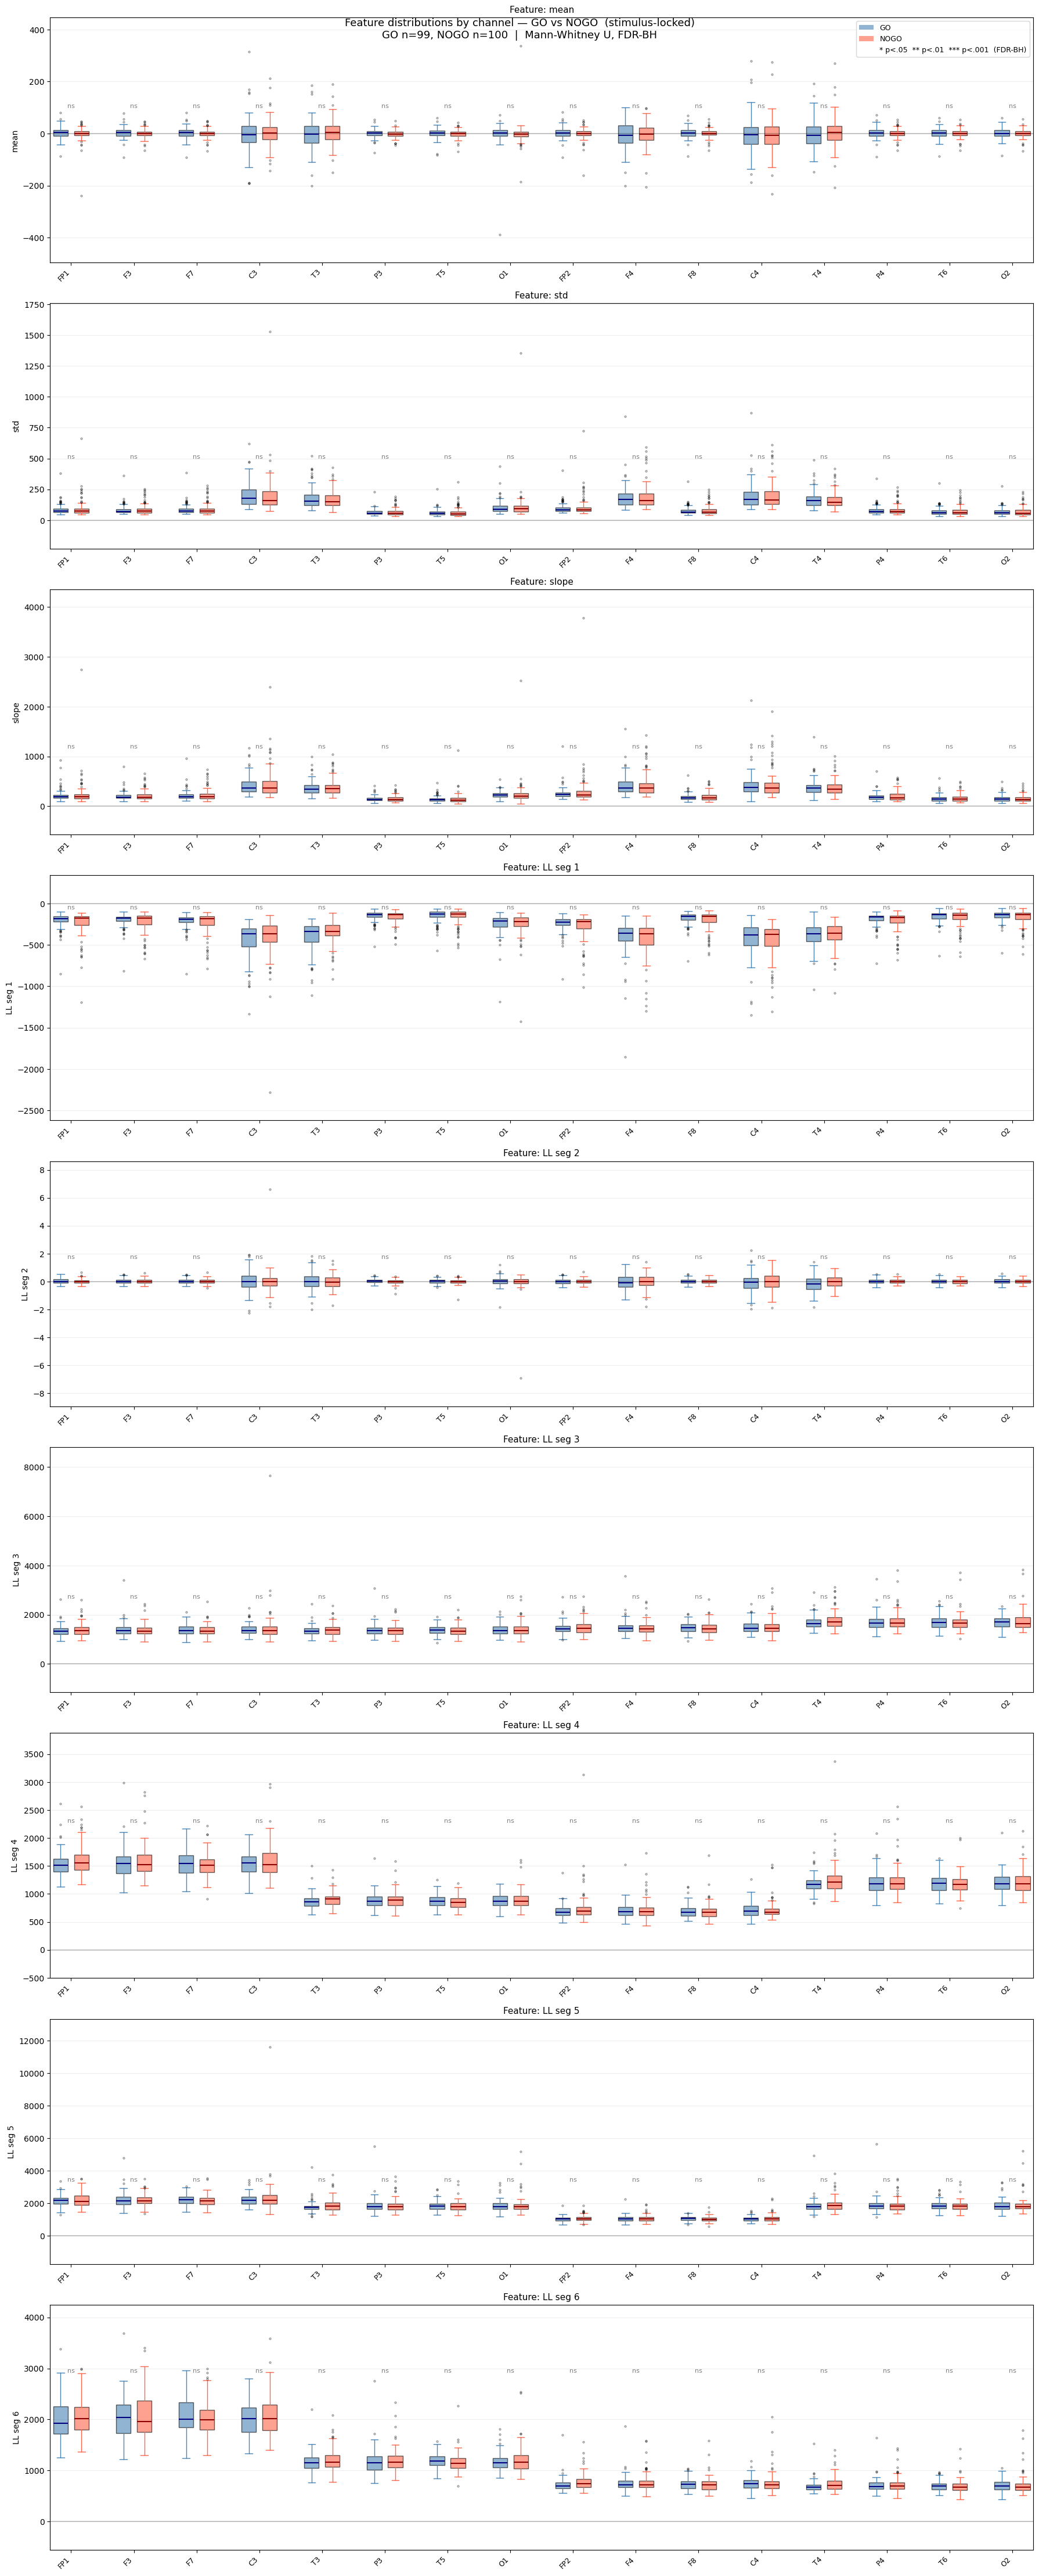

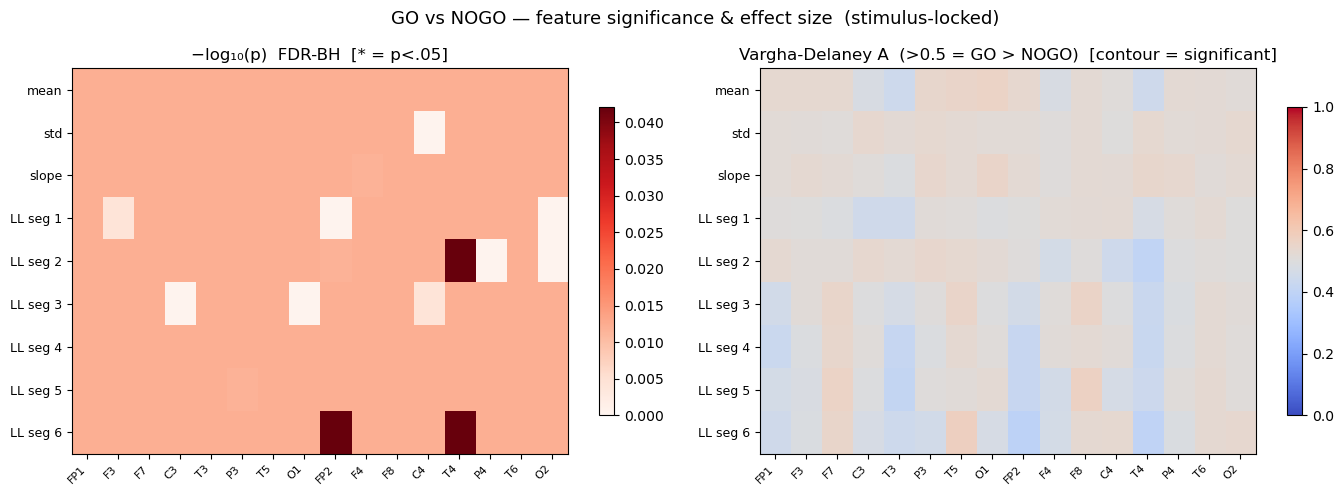

Significant feature×channel pairs (FDR p<.05): 0


In [33]:
# ── Feature boxplots + significance: GO vs NOGO (stimulus-locked) ────────────
from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests
from matplotlib.patches import Patch

X_go_gng   = epoch_feats(GO_ERP)
X_nogo_gng = epoch_feats(NOGO_ERP)

n_feats_per_ch = X_go_gng.shape[1] // N_CHANNELS
n_ll_segs      = n_feats_per_ch - 3            # however many LL segments epoch_feats used
feat_types_gng = ['mean', 'std', 'slope'] + [f'LL seg {i+1}' for i in range(n_ll_segs)]
n_feat_types   = len(feat_types_gng)

# FDR across all feature x channel pairs
raw_p_gng = []
for col in range(X_go_gng.shape[1]):
    _, p = mannwhitneyu(X_go_gng[:, col], X_nogo_gng[:, col], alternative='two-sided')
    raw_p_gng.append(p)

_, pvals_gng_fdr, _, _ = multipletests(raw_p_gng, method='fdr_bh')
pvals_gng_fdr = pvals_gng_fdr.reshape(n_feat_types, N_CHANNELS)

def pval_stars(p):
    if p < 0.001: return '***'
    if p < 0.01:  return '**'
    if p < 0.05:  return '*'
    return 'ns'

# ── Overview boxplot ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(n_feat_types, 1, figsize=(18, 5 * n_feat_types), sharex=False)

for fi, (ftype, ax) in enumerate(zip(feat_types_gng, axes)):
    cols    = np.arange(fi * N_CHANNELS, (fi + 1) * N_CHANNELS)
    go_vals = [X_go_gng[:, c]   for c in cols]
    ng_vals = [X_nogo_gng[:, c] for c in cols]

    pos_go = np.arange(N_CHANNELS) * 3
    pos_ng = pos_go + 1

    bp_go = ax.boxplot(go_vals, positions=pos_go, widths=0.7, patch_artist=True,
                       boxprops=dict(facecolor='steelblue', alpha=0.6),
                       medianprops=dict(color='navy', linewidth=1.5),
                       whiskerprops=dict(color='steelblue'), capprops=dict(color='steelblue'),
                       flierprops=dict(marker='o', markersize=2, color='steelblue', alpha=0.4))
    bp_ng = ax.boxplot(ng_vals, positions=pos_ng, widths=0.7, patch_artist=True,
                       boxprops=dict(facecolor='tomato', alpha=0.6),
                       medianprops=dict(color='darkred', linewidth=1.5),
                       whiskerprops=dict(color='tomato'), capprops=dict(color='tomato'),
                       flierprops=dict(marker='o', markersize=2, color='tomato', alpha=0.4))

    all_tops = [max(np.percentile(go_vals[ch], 95), np.percentile(ng_vals[ch], 95))
                for ch in range(N_CHANNELS)]
    y_annot = max(all_tops) * 1.05

    for ch in range(N_CHANNELS):
        p   = pvals_gng_fdr[fi, ch]
        lbl = pval_stars(p)
        mid = (pos_go[ch] + pos_ng[ch]) / 2
        ax.text(mid, y_annot, lbl, ha='center', va='bottom', fontsize=8,
                color='red' if p < 0.05 else 'gray',
                fontweight='bold' if p < 0.05 else 'normal')

    ax.set_xticks(pos_go + 0.5)
    ax.set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=9)
    ax.set_ylabel(ftype, fontsize=10)
    ax.axhline(0, color='k', linewidth=0.3)
    ax.set_title(f'Feature: {ftype}', fontsize=11)
    ax.grid(axis='y', linewidth=0.4, alpha=0.4)
    ax.margins(y=0.15)
    if fi == 0:
        ax.legend(handles=[Patch(facecolor='steelblue', alpha=0.6, label='GO'),
                            Patch(facecolor='tomato',    alpha=0.6, label='NOGO'),
                            plt.Line2D([], [], color='none',
                                       label='* p<.05  ** p<.01  *** p<.001  (FDR-BH)')],
                  loc='upper right', fontsize=9)

plt.suptitle(
    f'Feature distributions by channel — GO vs NOGO  (stimulus-locked)\n'
    f'GO n={GO_ERP.shape[0]}, NOGO n={NOGO_ERP.shape[0]}  |  Mann-Whitney U, FDR-BH',
    fontsize=13)
plt.tight_layout()
plt.show()

# ── Focused heatmap + individual boxplots for significant features ────────────
def vda(a, b):
    u, _ = mannwhitneyu(a, b, alternative='two-sided')
    return u / (len(a) * len(b))

sig_mask_gng = pvals_gng_fdr < 0.05
log_p_gng    = -np.log10(np.clip(pvals_gng_fdr, 1e-10, 1))

A_gng = np.zeros((n_feat_types, N_CHANNELS))
for fi in range(n_feat_types):
    for ch in range(N_CHANNELS):
        col = fi * N_CHANNELS + ch
        A_gng[fi, ch] = vda(X_go_gng[:, col], X_nogo_gng[:, col])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

im = axes[0].imshow(log_p_gng, aspect='auto', cmap='Reds', vmin=0)
for fi in range(n_feat_types):
    for ch in range(N_CHANNELS):
        if sig_mask_gng[fi, ch]:
            axes[0].text(ch, fi, '*', ha='center', va='center', fontsize=12,
                         color='black', fontweight='bold')
axes[0].set_xticks(range(N_CHANNELS)); axes[0].set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
axes[0].set_yticks(range(n_feat_types)); axes[0].set_yticklabels(feat_types_gng, fontsize=9)
axes[0].set_title('−log₁₀(p)  FDR-BH  [* = p<.05]')
plt.colorbar(im, ax=axes[0], shrink=0.8)

im2 = axes[1].imshow(A_gng, aspect='auto', cmap='coolwarm', vmin=0, vmax=1)
axes[1].contour(sig_mask_gng, levels=[0.5], colors='black', linewidths=1.2)
axes[1].set_xticks(range(N_CHANNELS)); axes[1].set_xticklabels(CHANNEL_NAMES, rotation=45, ha='right', fontsize=8)
axes[1].set_yticks(range(n_feat_types)); axes[1].set_yticklabels(feat_types_gng, fontsize=9)
axes[1].set_title('Vargha-Delaney A  (>0.5 = GO > NOGO)  [contour = significant]')
plt.colorbar(im2, ax=axes[1], shrink=0.8)

plt.suptitle('GO vs NOGO — feature significance & effect size  (stimulus-locked)', fontsize=13)
plt.tight_layout()
plt.show()

# ── Individual boxplots for significant pairs ─────────────────────────────────
sig_pairs_gng = [(fi, ch) for fi in range(n_feat_types) for ch in range(N_CHANNELS)
                 if sig_mask_gng[fi, ch]]
n_sig = len(sig_pairs_gng)
print(f"Significant feature×channel pairs (FDR p<.05): {n_sig}")

if n_sig > 0:
    ncols = min(n_sig, 6)
    nrows = (n_sig + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(3 * ncols, 4 * nrows), squeeze=False)
    axes_flat  = axes.flatten()

    for k, (fi, ch) in enumerate(sig_pairs_gng):
        ax  = axes_flat[k]
        col = fi * N_CHANNELS + ch
        g_v, n_v = X_go_gng[:, col], X_nogo_gng[:, col]
        bp = ax.boxplot([g_v, n_v], patch_artist=True,
                        medianprops=dict(color='black', linewidth=1.5),
                        flierprops=dict(marker='o', markersize=3, alpha=0.4))
        for patch, color in zip(bp['boxes'], ['steelblue', 'tomato']):
            patch.set_facecolor(color); patch.set_alpha(0.6)
        p = pvals_gng_fdr[fi, ch]
        stars = '***' if p < 0.001 else ('**' if p < 0.01 else '*')
        ax.set_title(f'{feat_types_gng[fi]}\n{CHANNEL_NAMES[ch]}  {stars} p={p:.3f}', fontsize=9)
        ax.set_xticks([1, 2]); ax.set_xticklabels(['GO', 'NOGO'], fontsize=9)
        ax.axhline(0, color='k', linewidth=0.3)

    for ax in axes_flat[n_sig:]:
        ax.set_visible(False)

    plt.suptitle('Significant features — GO vs NOGO  (stimulus-locked, FDR-BH)', fontsize=12)
    plt.tight_layout()
    plt.show()
